<a href="https://colab.research.google.com/github/marius-ne/CIE_ProjectB_Group13/blob/bozheng/Program_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIE 2025/26 RWTH, PROJECT B, GROUP 13
Junchao Yu, Marius Neuhalfen

ToDo:
- Find defective nodes by comparing perfect structure and imperfect structures for all scenarios
- Group defective nodes into regions (arc sections or track sections)
- Predict whether structure is perfect or imperfect
- Predict where the imperfection lies

There are 25.XXX for deformation and 24.XXX for stress

# Setup

In [1]:
import os
import sys
import itertools
import functools

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn

from pathlib import Path

In [2]:
pd.set_option('display.max_columns', 100)

## Data getting (if on Colab)

In [3]:
import google.colab
google.colab.drive.mount("/content/drive")

Mounted at /content/drive


Get ancillary data from Github

In [4]:
!git clone https://github.com/marius-ne/CIE_ProjectB_Group13.git

Cloning into 'CIE_ProjectB_Group13'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 101 (delta 56), reused 26 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (101/101), 4.60 MiB | 12.30 MiB/s, done.
Resolving deltas: 100% (56/56), done.


## Load data

In [5]:
os.chdir("CIE_ProjectB_Group13")

In [6]:
os.getcwd()

'/content/CIE_ProjectB_Group13'

**IMPORTANT:** You need to add a shortcut of the "programB" folder on GoogleDrive to your own "MyDrive" for this to work

In [7]:
!ln -s /content/drive/MyDrive/programB data

In [8]:
target_folder = "data/Data2"
current_folder = os.getcwd()

if Path(current_folder).name != target_folder:
    os.chdir(Path(current_folder) / Path(target_folder))
print(os.getcwd())


/content/drive/.shortcut-targets-by-id/1s4mXuvtXeACi0SlotRW51MJ2xu6p5JfN/programB/Data2


Convert data

In [9]:
VARIABLES = {
      0: "TotalDeformation.csv",
      1: "DirectionalDeformation_X_axis.csv",
      2: "DirectionalDeformation_Y_axis.csv",
      3: "DirectionalDeformation_Z_axis.csv",
      4: "EquivalentStress.csv",
      5: "ShearStress_XY.csv",
      6: "ShearStress_XZ.csv",
      7: "ShearStress_YZ.csv",
  }
LOADS = {
    0: "Bigger_train",
    1: "Smaller_train",
}
SEASONS = {
    0: "Summer",
    1: "Winter",
}
HEALTHS = {
    0: "Perfect_structure",
    1: "ip_frst_Arc_defect_all_tracks_111",
    2: "ip_1and3track_3_arc_78910",
    3: "ip_first_track_3arc_78910",
    4: "Ip_1track_1_arc_345",
    5: "ip_3track_1_arc_678",
    6: "ip_2_arc_all_tracks_222",
}
TRAIN_CONFIGS = {
    0: "One_train_1st_track",
    1: "One_train_middle_track",
    2: "Two_trains_extreme_track_different_direction",
    3: "Two_trains_extreme_track_same_direction",
}
VARIABLE_NAMES = [var[:-4] for var in VARIABLES.values()]
NODE_NUMBERS = None

def combination_to_string(combination):
    train_config, load, season, health, variable = combination
    return f"{TRAIN_CONFIGS[train_config]}__{LOADS[load]}__{SEASONS[season]}__{HEALTHS[health]}__{VARIABLES[variable][:-4]}"

# Construct list of scenarios (combinations of train configs, loads, seasons, healths, variables)
#   Each scenario is a tuple of (train_config, load, season, health, variable), each encoded
#   as the corresponding key in the dictionaries above
combinations = itertools.product(
        TRAIN_CONFIGS.keys(),
        LOADS.keys(),
        SEASONS.keys(),
        HEALTHS.keys(),
        VARIABLES.keys()
    )
combinations = list(combinations)

# Group by variables, i.e. each group has all variables for one scenario
combinations_grouped_by_variable = [
    combinations[i:i + len(VARIABLES)] for i in range(0, len(combinations), len(VARIABLES))
]
# Group further by healths, i.e. each group has all healths for one scenario (train config, load, season)
combinations_grouped_by_health = [
    combinations_grouped_by_variable[i:i + len(HEALTHS)] for i in range(0, len(combinations_grouped_by_variable), len(HEALTHS))
]



In [10]:
combinations_grouped_by_health[0]

[[(0, 0, 0, 0, 0),
  (0, 0, 0, 0, 1),
  (0, 0, 0, 0, 2),
  (0, 0, 0, 0, 3),
  (0, 0, 0, 0, 4),
  (0, 0, 0, 0, 5),
  (0, 0, 0, 0, 6),
  (0, 0, 0, 0, 7)],
 [(0, 0, 0, 1, 0),
  (0, 0, 0, 1, 1),
  (0, 0, 0, 1, 2),
  (0, 0, 0, 1, 3),
  (0, 0, 0, 1, 4),
  (0, 0, 0, 1, 5),
  (0, 0, 0, 1, 6),
  (0, 0, 0, 1, 7)],
 [(0, 0, 0, 2, 0),
  (0, 0, 0, 2, 1),
  (0, 0, 0, 2, 2),
  (0, 0, 0, 2, 3),
  (0, 0, 0, 2, 4),
  (0, 0, 0, 2, 5),
  (0, 0, 0, 2, 6),
  (0, 0, 0, 2, 7)],
 [(0, 0, 0, 3, 0),
  (0, 0, 0, 3, 1),
  (0, 0, 0, 3, 2),
  (0, 0, 0, 3, 3),
  (0, 0, 0, 3, 4),
  (0, 0, 0, 3, 5),
  (0, 0, 0, 3, 6),
  (0, 0, 0, 3, 7)],
 [(0, 0, 0, 4, 0),
  (0, 0, 0, 4, 1),
  (0, 0, 0, 4, 2),
  (0, 0, 0, 4, 3),
  (0, 0, 0, 4, 4),
  (0, 0, 0, 4, 5),
  (0, 0, 0, 4, 6),
  (0, 0, 0, 4, 7)],
 [(0, 0, 0, 5, 0),
  (0, 0, 0, 5, 1),
  (0, 0, 0, 5, 2),
  (0, 0, 0, 5, 3),
  (0, 0, 0, 5, 4),
  (0, 0, 0, 5, 5),
  (0, 0, 0, 5, 6),
  (0, 0, 0, 5, 7)],
 [(0, 0, 0, 6, 0),
  (0, 0, 0, 6, 1),
  (0, 0, 0, 6, 2),
  (0, 0, 0, 6, 3),
  (0, 

In [11]:
def read_data_file(
    train_config: int = 0,
    load: int = 0,
    season: int = 0,
    health: int = 0,
    variable: int = 0,
):
  """Reads data according to format and provides the data-frame as-is, with
  the categorical variables added as columns."""

  # Construct filename from scenario according to the folder structure

  results_paths = ["Results", "Results1"]

  for results_path in results_paths:
      filename = Path()
      filename /= TRAIN_CONFIGS[train_config]
      filename /= LOADS[load]
      filename /= SEASONS[season]
      filename /= HEALTHS[health]
      filename /= results_path
      filename /= VARIABLES[variable]

      if filename.exists():
          break
  else:
      raise FileNotFoundError(f"Data file not found for combination: {combination_to_string((train_config, load, season, health, variable))}")

  # Encode the scenario as categorical columns
  #   -> TODO: Is there a way of encoding that
  #   preserves information? E.g. like encoding the name of a city as its latitude
  df = pd.read_csv(filename)
  num_nodes = len(df)
  df["season"] = season*np.ones(num_nodes,dtype=np.uint8)
  df["health"] = health*np.ones(num_nodes,dtype=np.uint8)
  df["load"] = load*np.ones(num_nodes,dtype=np.uint8)
  df["train_config"] = train_config*np.ones(num_nodes,dtype=np.uint8)

  return df


def get_data():
  """
  Reads all data files from one health group and merges them
  into a single data-frame.
  TODO: Make it read all scenarios, not just one.

  Returns:
      pd.DataFrame: Merged data-frame with all variables as columns.
  """
  global NODE_NUMBERS

  # Select one scenario that has same season, load and trains and goes through
  #   all healths and variables
  scenario = combinations_grouped_by_health[0] # TBD

  # Merge data for all healths in the scenario
  dfs_healths = []
  for same_health_combinations in scenario:
    dfs_variables = []

    #  Merge data for all variables in the current health scenario
    for same_variable_combination in same_health_combinations:
      print("Processing combination:", combination_to_string(same_variable_combination))

      var_name = VARIABLE_NAMES[same_variable_combination[-1]]

      # Get data file for current combination
      df = read_data_file(*same_variable_combination)

      # Turn the variable column into a single one and add a new time column
      df_melted = df.melt(id_vars=["Node Number","season","load","health","train_config"],var_name="variable",value_name=var_name)
      df_melted["time"] = df_melted["variable"].str[-3:].astype(np.float64)
      df_melted.drop(columns=["variable"],inplace=True)

      # Get node numbers and ensure they're consistent
      if NODE_NUMBERS is None:
        NODE_NUMBERS = df_melted["Node Number"].unique()
      else:
        try:
          assert all(NODE_NUMBERS == df_melted["Node Number"].unique())
        except ValueError or AssertionError:
          print("WARNING: Node numbers differ between data files!")
          print("Previous node numbers:", NODE_NUMBERS)
          print("Current node numbers:", df_melted["Node Number"].unique())

      dfs_variables.append(df_melted)

    # Concatenating all variables into a single data frame
    # -> we do an OUTER join, meaning all keys are kept (A U B)
    #   this should be safe, node numbers and the other shared columns are kept
    shared_cols = ["Node Number","season","load","health","train_config","time"]
    df_vars = functools.reduce(lambda left,right: pd.merge(left,right,on=shared_cols,
                                              how='outer'), dfs_variables)
    # Check that data has been preserved
    for df in dfs_variables:
      for var_name in VARIABLE_NAMES:
        if var_name in df.columns:
          merged = pd.merge(df[shared_cols + [var_name]], df_vars[shared_cols + [var_name]],
                            on=shared_cols, how='inner')
          assert len(merged) == len(df)

    dfs_healths.append(df_vars)

  # Check that columns are the same
  assert all(all(df.columns == dfs_healths[0].columns) for df in dfs_healths)

  # Concatenate them together
  df = pd.concat(dfs_healths,ignore_index=True)

  return df

df = get_data()

Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__TotalDeformation
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__DirectionalDeformation_X_axis
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__DirectionalDeformation_Y_axis
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__DirectionalDeformation_Z_axis
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__EquivalentStress
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__ShearStress_XY
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__ShearStress_XZ
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__ShearStress_YZ
Processing combination: One_train_1st_track__Bigger_train__Summer__ip_frst_Arc_defect_all_tracks_111__TotalDeformation
Processing combination: 

In [12]:
df

,Node Number,season,load,health,train_config,TotalDeformation,time,DirectionalDeformation_X_axis,DirectionalDeformation_Y_axis,DirectionalDeformation_Z_axis,EquivalentStress,ShearStress_XY,ShearStress_XZ,ShearStress_YZ
0,1,0,0,0,0,0.000010,0.1,0.000003,0.000009,2.279800e-06,8727600.0,-392110.0,216100.0,517780.0
1,1,0,0,0,0,0.000011,0.5,0.000004,0.000009,4.379000e-06,14175000.0,-973950.0,420700.0,1028900.0
2,1,0,0,0,0,0.000010,0.9,0.000003,0.000009,2.283200e-06,8729500.0,-390000.0,216280.0,518170.0
3,1,0,0,0,0,0.000009,1.1,0.000004,0.000008,6.102300e-07,6162300.0,-2256900.0,-48168.0,13718.0
4,1,0,0,0,0,0.000010,1.5,0.000005,0.000008,1.077800e-06,10044000.0,-4697700.0,-115360.0,-3011.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1790665,25581,0,0,6,0,NaN,1.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1790666,25581,0,0,6,0,NaN,2.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1790667,25581,0,0,6,0,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1790668,25581,0,0,6,0,NaN,2.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Analyze node numbers

Go through all data files and check number of nodes. Create csv file that recaps these.

In [13]:
nums = []
for ix, combination in enumerate(combinations):
    num_nodes = len(read_data_file(*combination)["Node Number"].unique())
    entry = {}
    entry["train_config"] = combination[0]
    entry["load"] = combination[1]
    entry["season"] = combination[2]
    entry["health"] = combination[3]
    entry["variable"] = combination[4]
    entry["num_nodes"] = num_nodes
    nums.append(entry)
nums

[{'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 0,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 1,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 2,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 3,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 4,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 5,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 6,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 7,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 1,
  'variable': 0,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 1,


Exemplary plot of node numbers throughout a number of scenarios.

<Axes: title={'center': 'Num. nodes per health state'}, xlabel='health'>

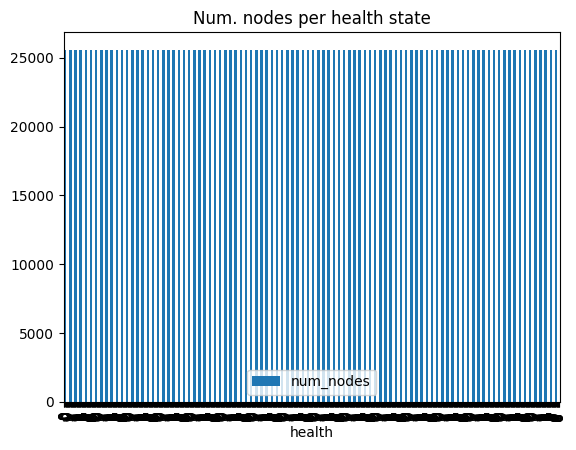

In [14]:
nn_df = pd.DataFrame(nums)
nn_df.plot(
    x="health", y="num_nodes", kind="bar",
    title=f"Num. nodes per health state"
)

In [15]:
# Save recap to file
# nn_df.to_csv("node_numbers_Data2_overview.csv", index=False)

# Visualize bridge structure

In [17]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import os
os.listdir("/content/drive/MyDrive")[:50]


['Colab Notebooks', 'programB (1)', 'programB']

In [19]:
import os

target = "nodeExport.txt"
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if target in files:
        print("找到了：", os.path.join(root, target))
        break


找到了： /content/drive/MyDrive/programB (1)/CIE_ProjectB_Group13/Data2/nodeExport.txt


In [20]:
# Read tab separated node export file
node_xyz = pd.read_csv(
    "/content/drive/MyDrive/programB (1)/CIE_ProjectB_Group13/Data2/nodeExport.txt",
    sep="\t",
    engine="python"
)


In [21]:
def select_df_subset(combination):
    """Selects a subset of the main data-frame according to the given combination.

    Args:
        combination (tuple): A tuple of (train_config, load, season, health, variable).
    """
    train_config, load, season, health, variable = combination
    var_name = VARIABLE_NAMES[variable]
    df_subset = df[
        (df["train_config"] == train_config) &
        (df["load"] == load) &
        (df["season"] == season) &
        (df["health"] == health)
    ][["Node Number", "time", var_name]]
    return df_subset

In [22]:
from ipywidgets import interact, FloatSlider

# Colors for missing nodes
missing_color = 'r'
missing_nn = {}
colors = [
    missing_color if nn in missing_nn.values() else 'b'
    for nn in node_xyz["Node Number"]
]

cmap = plt.get_cmap('viridis')

# Colors for bridge loads
combination = (0, 0, 0, 3, 0)  # Example combination

def plot_bridge_loads_3d_slider(combination):
    """
    Plots bridge loads in 3D with a time slider.
    Args:
        combination (tuple): A tuple of (train_config, load, season, health, variable).
    """
    df_subset = select_df_subset(combination)
    time_points = np.sort(df_subset["time"].unique())
    variable_to_plot = VARIABLE_NAMES[combination[-1]]

    def plot_at_time(time_point_index):
        time_point = time_points[int(time_point_index)]
        timestamp_subset = df_subset[df_subset["time"] == time_point]
        node_loads = [
            timestamp_subset[timestamp_subset["Node Number"] == nn][variable_to_plot].values
            for nn in node_xyz["Node Number"]
        ]
        node_loads_flat = [nl[0] if len(nl) > 0 else np.nan for nl in node_loads]

        fig = plt.figure(figsize=(10,10))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(
            node_xyz["X Location (m)"],
            node_xyz["Y Location (m)"],
            node_xyz["Z Location (m)"],
            c=node_loads_flat, marker='o', s=2,
            cmap="viridis"
        )
        fig.colorbar(scatter, shrink=0.5)
        ax.set_title(f"Bridge Loads at time {time_point}\nFor combination: {combination_to_string(combination)}")
        fig.savefig(f"../visualization/bridge_loads_3d_{time_point}.png")
        # fig.show()

    interact(
        plot_at_time,
        time_point_index=FloatSlider(
            min=0,
            max=len(time_points)-1,
            step=1,
            value=0,
            description='Time Index'
        )
    )

plot_bridge_loads_3d_slider(combination)

interactive(children=(FloatSlider(value=0.0, description='Time Index', max=9.0, step=1.0), Output()), _dom_cla…

Create GIF from visualizations

In [25]:
import numpy as np
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from pathlib import Path

def create_gif_bridge_loads(
    combination,
    viz_dir="/content/drive/MyDrive/programB (1)/CIE_ProjectB_Group13/Data2/CIE_ProjectB_Group13/visualization",
    gif_name="bridge_loads_animation.gif",
    duration=0.5,
    dpi=150
):
    viz_dir = Path(viz_dir)
    viz_dir.mkdir(parents=True, exist_ok=True)

    df_subset = select_df_subset(combination)
    time_points = np.sort(df_subset["time"].unique())
    if len(time_points) == 0:
        raise ValueError("df_subset 为空：这个 combination 在 df 里没有数据")

    var = VARIABLE_NAMES[combination[-1]]


    vmin = df_subset[var].min(skipna=True)
    vmax = df_subset[var].max(skipna=True)

    frames = []

    for t in time_points:
        timestamp_subset = df_subset[df_subset["time"] == t]


        node_vals = []
        for nn in node_xyz["Node Number"]:
            arr = timestamp_subset.loc[timestamp_subset["Node Number"] == nn, var].values
            node_vals.append(arr[0] if len(arr) > 0 else np.nan)

        fig = plt.figure(figsize=(10, 10), dpi=dpi)
        canvas = FigureCanvas(fig)
        ax = fig.add_subplot(111, projection="3d")

        sc = ax.scatter(
            node_xyz["X Location (m)"],
            node_xyz["Y Location (m)"],
            node_xyz["Z Location (m)"],
            c=node_vals, s=2, cmap="viridis",
            vmin=vmin, vmax=vmax
        )
        fig.colorbar(sc, shrink=0.5)
        ax.set_title(f"Bridge Loads at time {t}\n{combination_to_string(combination)}")

        canvas.draw()
        frame = np.asarray(canvas.buffer_rgba())[:, :, :3]  # RGB
        frames.append(frame)

        plt.close(fig)

    gif_path = viz_dir / gif_name
    imageio.mimsave(gif_path, frames, duration=duration)
    print("GIF saved to:", gif_path)
    return gif_path


combination = (0, 0, 0, 3, 0)
gif_path = create_gif_bridge_loads(combination, duration=0.5)


GIF saved to: /content/drive/MyDrive/programB (1)/CIE_ProjectB_Group13/Data2/CIE_ProjectB_Group13/visualization/bridge_loads_animation.gif


# Remove NaN

Stress columns used: ['EquivalentStress', 'ShearStress_XY', 'ShearStress_XZ', 'ShearStress_YZ']
Target health ids: [1, 3, 5, 6, 4, 2]  (perfect=0)

Scenario: ip_frst_Arc_defect_all_tracks_111 (health=1)  VS  Perfect_structure (health=0)
Comparable nodes: 25581
Changed nodes count: 3761
Changed ratio: 0.147023

Changed node numbers (ALL):
[9, 17, 23, 28, 29, 49, 50, 63, 74, 78, 81, 83, 89, 90, 96, 101, 102, 104, 107, 113, 118, 126, 127, 130, 131, 137, 147, 148, 149, 154, 167, 178, 192, 197, 212, 223, 225, 240, 241, 253, 268, 321, 357, 359, 369, 406, 407, 411, 445, 458, 464, 482, 492, 493, 498, 507, 513, 567, 571, 577, 597, 601, 631, 640, 648, 652, 671, 672, 673, 675, 687, 690, 697, 708, 709, 711, 715, 747, 748, 751, 752, 755, 766, 767, 768, 771, 782, 791, 792, 807, 809, 811, 812, 813, 815, 822, 827, 830, 833, 834, 841, 842, 843, 844, 846, 848, 849, 851, 852, 853, 856, 858, 859, 860, 866, 871, 872, 874, 887, 888, 889, 895, 899, 900, 903, 907, 909, 912, 918, 922, 923, 925, 926, 930, 935, 

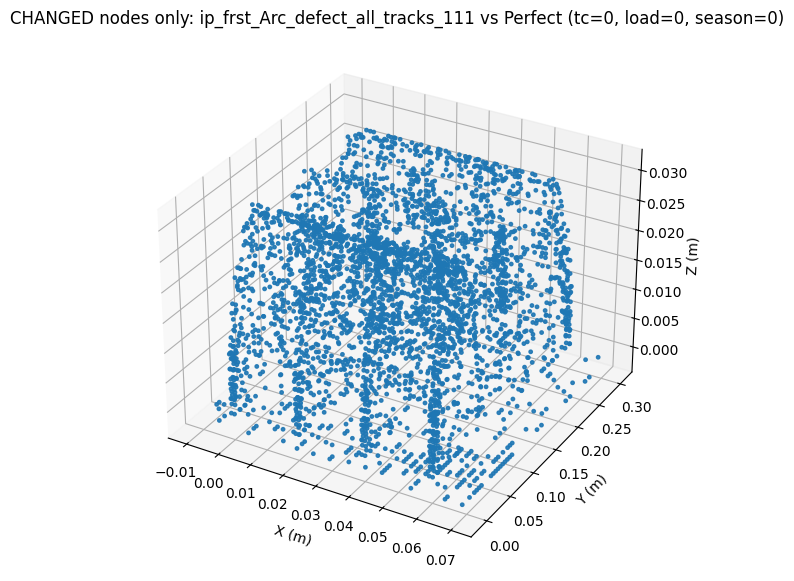

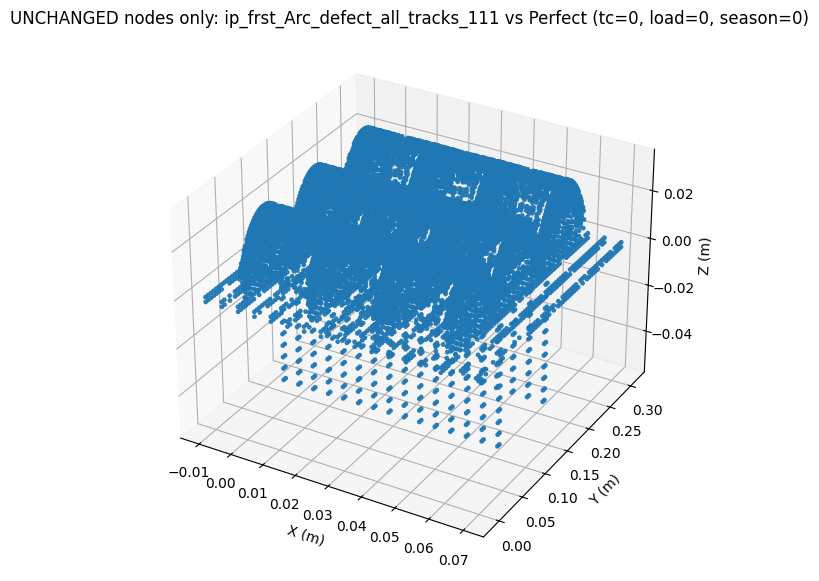


Scenario: ip_first_track_3arc_78910 (health=3)  VS  Perfect_structure (health=0)
Comparable nodes: 25581
Changed nodes count: 834
Changed ratio: 0.032602

Changed node numbers (ALL):
[9, 28, 83, 90, 96, 111, 116, 118, 121, 126, 131, 148, 149, 212, 225, 236, 268, 387, 672, 697, 711, 752, 768, 807, 827, 838, 843, 844, 849, 853, 856, 860, 872, 895, 899, 900, 903, 918, 952, 961, 965, 968, 969, 973, 990, 1001, 1035, 1037, 1041, 1067, 1068, 1090, 1134, 1145, 1174, 1184, 1434, 1437, 1480, 1515, 1591, 1634, 1684, 1730, 1739, 1797, 1836, 1840, 1847, 1853, 1869, 1907, 1968, 1996, 2003, 2016, 2032, 2042, 2055, 2071, 2131, 2152, 2341, 2349, 2350, 2352, 2354, 2359, 2439, 2450, 2490, 2521, 2534, 2546, 2588, 2607, 2608, 2610, 2613, 2614, 2616, 2621, 2626, 2666, 2682, 2683, 2712, 2716, 2717, 2741, 2750, 2788, 2805, 2812, 2813, 2823, 2824, 2826, 2827, 2828, 2836, 2837, 2881, 2998, 2999, 3019, 3022, 3058, 3059, 3060, 3076, 3082, 3085, 3086, 3089, 3090, 3091, 3101, 3110, 3133, 3172, 3196, 3198, 3203, 32

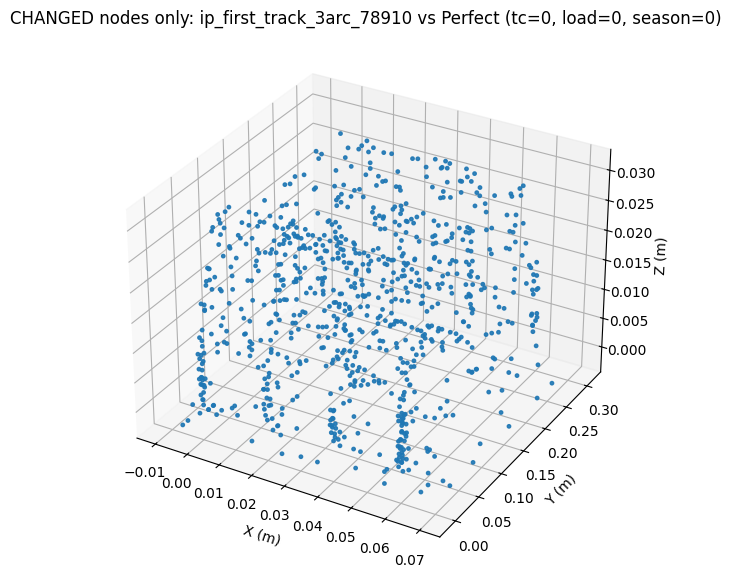

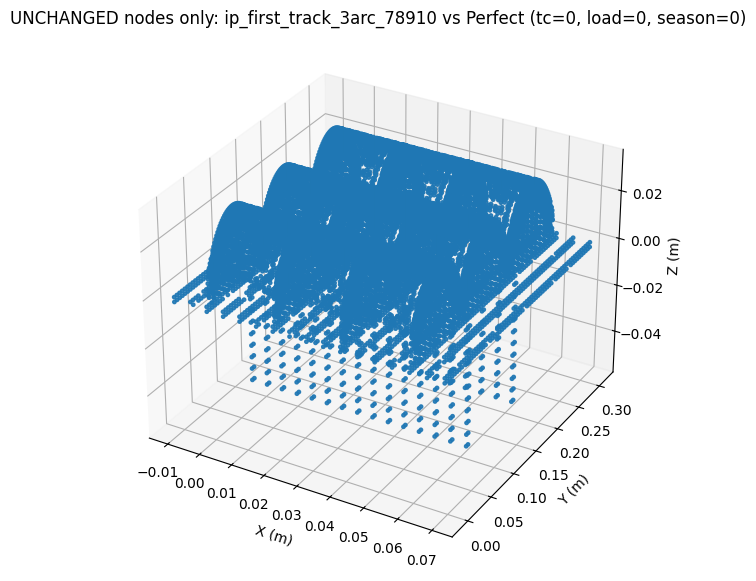


Scenario: ip_3track_1_arc_678 (health=5)  VS  Perfect_structure (health=0)
Comparable nodes: 25581
Changed nodes count: 1550
Changed ratio: 0.060592

Changed node numbers (ALL):
[9, 17, 18, 23, 47, 48, 49, 55, 59, 76, 81, 83, 90, 94, 106, 108, 109, 111, 113, 116, 118, 119, 121, 122, 125, 126, 130, 136, 142, 148, 151, 156, 166, 169, 175, 181, 192, 212, 223, 225, 229, 236, 240, 241, 253, 284, 373, 387, 406, 491, 493, 603, 654, 672, 711, 727, 752, 768, 827, 843, 844, 849, 856, 860, 872, 875, 895, 899, 900, 918, 952, 961, 973, 1001, 1035, 1037, 1061, 1068, 1080, 1090, 1112, 1113, 1134, 1143, 1145, 1184, 1186, 1232, 1287, 1291, 1293, 1322, 1409, 1420, 1424, 1427, 1435, 1468, 1512, 1633, 1634, 1635, 1641, 1684, 1695, 1700, 1706, 1714, 1716, 1730, 1732, 1739, 1740, 1750, 1751, 1762, 1770, 1773, 1783, 1784, 1797, 1799, 1812, 1814, 1825, 1829, 1832, 1836, 1840, 1847, 1859, 1873, 1884, 1889, 1890, 1907, 1935, 1952, 1971, 1975, 1976, 1987, 1991, 1994, 2002, 2003, 2004, 2009, 2016, 2032, 2042, 20

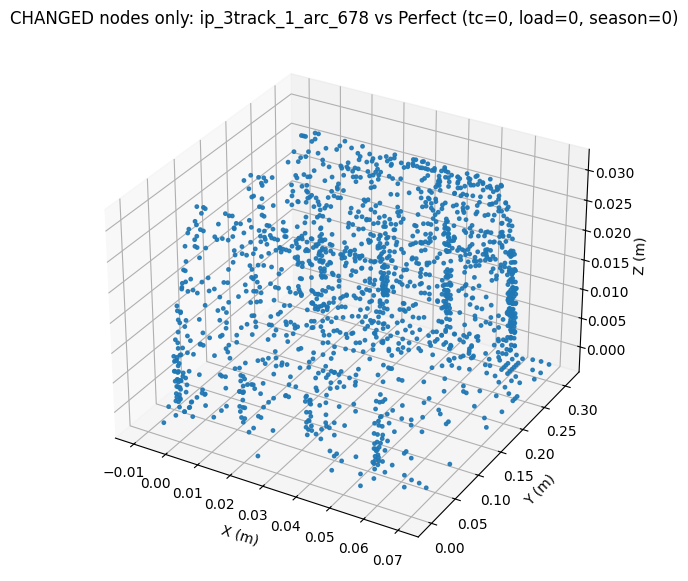

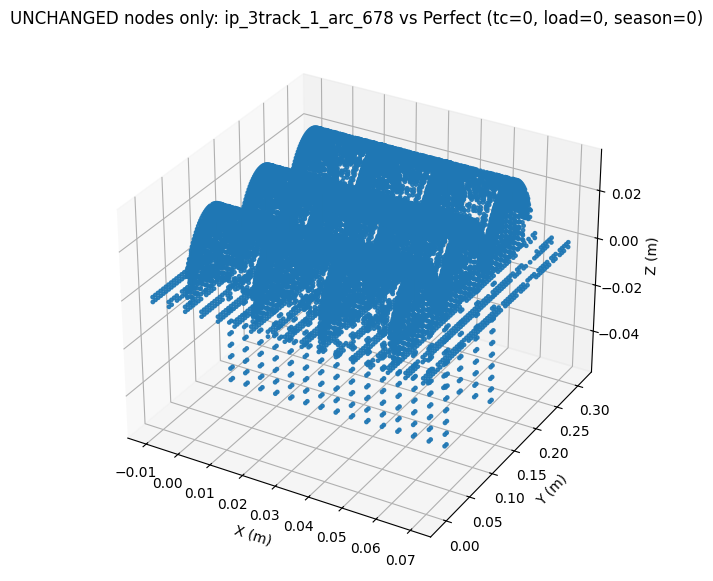


Scenario: ip_2_arc_all_tracks_222 (health=6)  VS  Perfect_structure (health=0)
Comparable nodes: 25581
Changed nodes count: 3060
Changed ratio: 0.119620

Changed node numbers (ALL):
[6, 9, 17, 28, 49, 63, 78, 83, 90, 91, 96, 101, 104, 105, 107, 116, 126, 127, 129, 130, 131, 137, 147, 148, 154, 167, 192, 212, 223, 225, 236, 237, 268, 320, 359, 369, 406, 407, 411, 458, 492, 493, 513, 601, 631, 640, 648, 652, 671, 672, 673, 675, 690, 692, 697, 702, 708, 709, 715, 727, 738, 747, 748, 751, 766, 767, 768, 771, 792, 807, 809, 812, 813, 815, 822, 827, 833, 834, 841, 843, 844, 846, 848, 849, 852, 853, 856, 858, 859, 860, 866, 872, 874, 887, 889, 891, 899, 903, 907, 909, 918, 922, 923, 925, 926, 930, 937, 951, 952, 953, 960, 965, 968, 969, 970, 973, 978, 986, 991, 993, 994, 996, 1001, 1002, 1004, 1005, 1009, 1014, 1016, 1017, 1020, 1024, 1029, 1033, 1035, 1037, 1041, 1045, 1047, 1048, 1050, 1055, 1064, 1065, 1071, 1078, 1079, 1083, 1089, 1090, 1100, 1101, 1107, 1110, 1112, 1122, 1125, 1126, 113

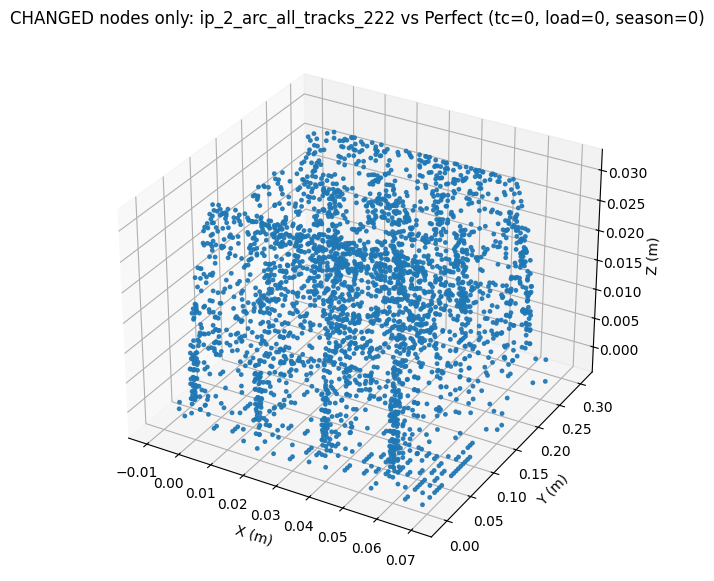

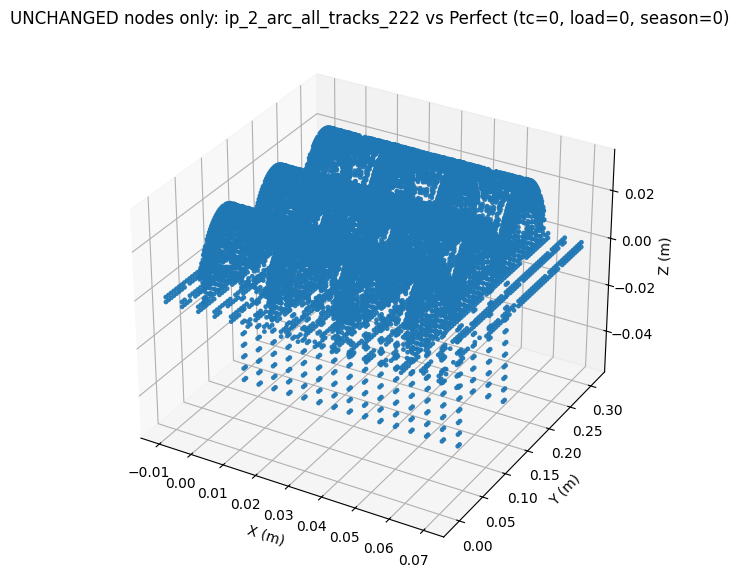


Scenario: Ip_1track_1_arc_345 (health=4)  VS  Perfect_structure (health=0)
Comparable nodes: 25581
Changed nodes count: 568
Changed ratio: 0.022204

Changed node numbers (ALL):
[9, 28, 74, 83, 90, 101, 113, 118, 131, 142, 147, 148, 154, 182, 192, 225, 359, 387, 507, 672, 673, 766, 772, 830, 833, 839, 842, 885, 889, 895, 899, 900, 904, 908, 960, 969, 973, 1001, 1008, 1016, 1019, 1057, 1065, 1110, 1134, 1145, 1153, 1155, 1184, 1199, 1224, 1232, 1293, 1355, 1409, 1434, 1684, 1714, 1719, 1724, 1836, 1853, 1859, 1873, 1952, 1971, 1991, 1996, 2005, 2037, 2053, 2055, 2347, 2352, 2359, 2382, 2415, 2448, 2450, 2465, 2607, 2613, 2614, 2628, 2666, 2745, 2828, 2836, 2881, 2900, 2908, 3019, 3091, 3249, 3321, 3355, 3364, 3434, 3562, 3565, 3595, 3612, 3620, 3626, 3675, 3706, 3716, 3742, 3764, 3835, 3847, 3852, 3930, 3983, 3989, 3995, 4044, 4097, 4101, 4102, 4193, 4267, 4269, 4276, 4326, 4333, 4374, 4379, 4381, 4435, 4520, 4533, 4578, 4606, 4631, 4637, 4638, 4653, 4676, 4841, 4846, 4847, 4852, 4888, 

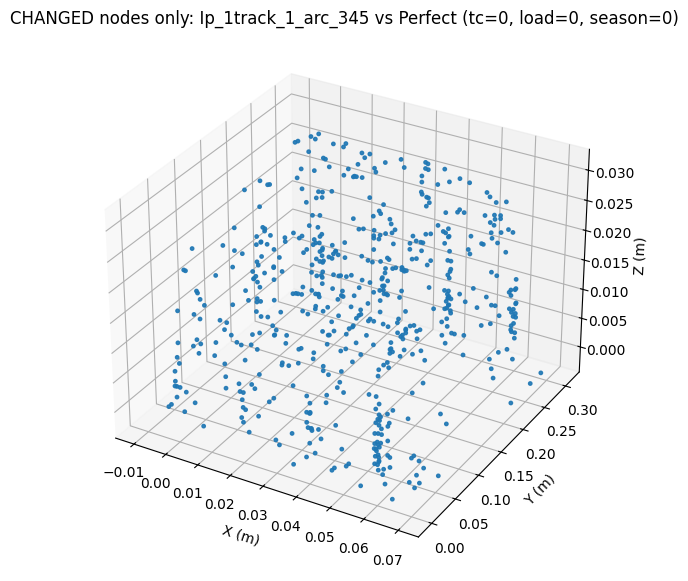

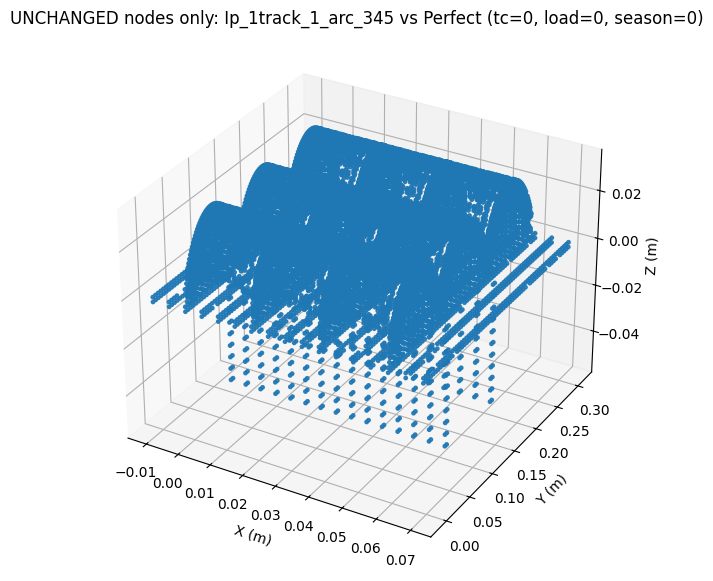


Scenario: ip_1and3track_3_arc_78910 (health=2)  VS  Perfect_structure (health=0)
Comparable nodes: 25581
Changed nodes count: 3549
Changed ratio: 0.138736

Changed node numbers (ALL):
[9, 14, 17, 50, 63, 81, 83, 90, 96, 101, 102, 104, 109, 111, 116, 118, 126, 127, 133, 147, 149, 167, 182, 212, 223, 225, 227, 228, 229, 236, 267, 268, 306, 321, 351, 357, 365, 369, 387, 406, 421, 432, 437, 438, 449, 464, 472, 477, 483, 493, 506, 507, 513, 559, 561, 567, 597, 631, 635, 648, 671, 672, 693, 697, 709, 711, 727, 747, 748, 768, 771, 786, 803, 807, 809, 813, 822, 827, 833, 838, 841, 843, 844, 849, 852, 856, 859, 860, 872, 873, 874, 875, 876, 889, 897, 899, 900, 903, 912, 918, 922, 923, 925, 930, 937, 948, 952, 961, 965, 968, 969, 970, 973, 976, 978, 986, 990, 991, 996, 998, 1001, 1002, 1009, 1020, 1025, 1026, 1027, 1035, 1037, 1041, 1043, 1047, 1064, 1067, 1071, 1078, 1080, 1086, 1089, 1090, 1097, 1109, 1110, 1122, 1134, 1138, 1143, 1145, 1154, 1169, 1170, 1174, 1179, 1183, 1184, 1199, 1205, 12

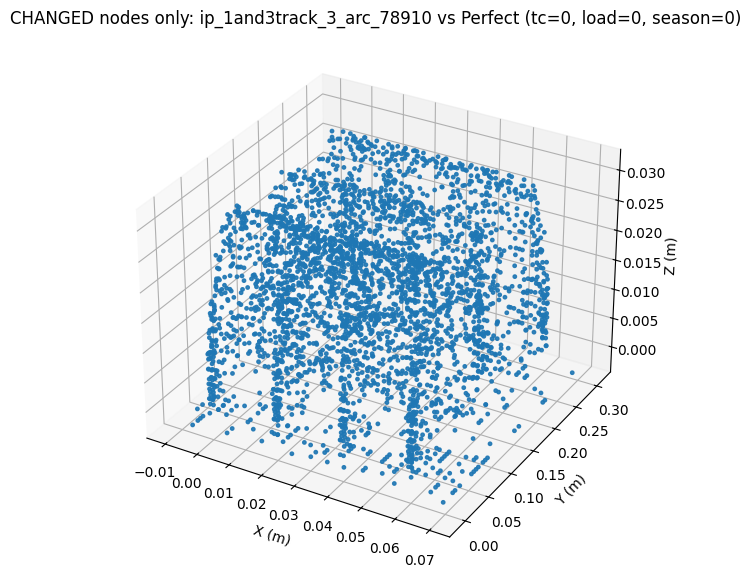

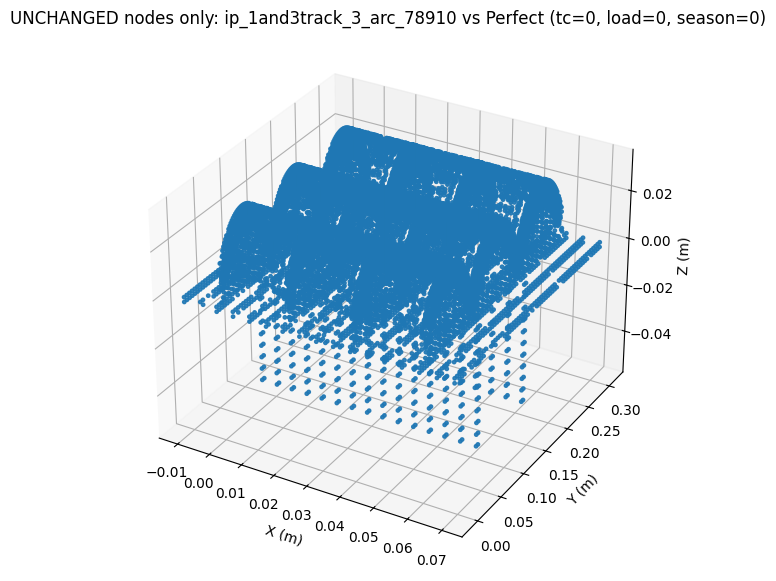

,health,scenario,n_nodes,n_changed,changed_ratio
0,1,ip_frst_Arc_defect_all_tracks_111,25581,3761,0.147023
1,2,ip_1and3track_3_arc_78910,25581,3549,0.138736
2,3,ip_first_track_3arc_78910,25581,834,0.032602
3,4,Ip_1track_1_arc_345,25581,568,0.022204
4,5,ip_3track_1_arc_678,25581,1550,0.060592
5,6,ip_2_arc_all_tracks_222,25581,3060,0.119620



Saved summary CSV.


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df_use = df_sorted if "df_sorted" in globals() else df


train_config = 0  # One_train_1st_track
load = 0          # Bigger_train
season = 0        # Summer


stress_cols = [c for c in VARIABLE_NAMES if "Stress" in c]
print("Stress columns used:", stress_cols)

HEALTHS = {
    0: "Perfect_structure",
    1: "ip_frst_Arc_defect_all_tracks_111",
    2: "ip_1and3track_3_arc_78910",
    3: "ip_first_track_3arc_78910",
    4: "Ip_1track_1_arc_345",
    5: "ip_3track_1_arc_678",
    6: "ip_2_arc_all_tracks_222",
}


target_names = [
    "ip_frst_Arc_defect_all_tracks_111",
    "ip_first_track_3arc_78910",
    "ip_3track_1_arc_678",
    "ip_2_arc_all_tracks_222",
    "ip_1track_1_arc_345",
    "ip_1and3track_3_arc_78910",
]


name2id = {v.lower(): k for k, v in HEALTHS.items()}
target_health_ids = []
for nm in target_names:
    key = nm.lower()
    if key not in name2id:
        raise ValueError(f"Cannot find health id for scenario name: {nm}. Available: {list(name2id.keys())}")
    target_health_ids.append(name2id[key])

print("Target health ids:", target_health_ids, " (perfect=0)")


def compare_stress_to_perfect(
    df_use: pd.DataFrame,
    train_config: int,
    load: int,
    season: int,
    health_cmp: int,
    stress_cols: list[str],
    eps: float = 0.0
):
    df_base = df_use[
        (df_use["train_config"] == train_config) &
        (df_use["load"] == load) &
        (df_use["season"] == season) &
        (df_use["health"] == 0)
    ][["Node Number", "time"] + stress_cols].copy()

    df_cmp = df_use[
        (df_use["train_config"] == train_config) &
        (df_use["load"] == load) &
        (df_use["season"] == season) &
        (df_use["health"] == health_cmp)
    ][["Node Number", "time"] + stress_cols].copy()

    merged = pd.merge(
        df_base, df_cmp,
        on=["Node Number", "time"],
        suffixes=("_base", "_cmp"),
        how="inner"
    )


    diffs = []
    for c in stress_cols:
        diffs.append((merged[f"{c}_cmp"] - merged[f"{c}_base"]).abs().to_numpy())
    D = np.vstack(diffs).T
    merged["row_max_stress_diff"] = D.max(axis=1)


    node_max_diff = merged.groupby("Node Number")["row_max_stress_diff"].max()

    changed_nodes   = node_max_diff.index[node_max_diff >  eps].to_numpy(dtype=int)
    unchanged_nodes = node_max_diff.index[node_max_diff <= eps].to_numpy(dtype=int)

    total_nodes = int(node_max_diff.shape[0])
    changed_ratio = len(changed_nodes) / total_nodes if total_nodes > 0 else np.nan

    return changed_nodes, unchanged_nodes, changed_ratio, total_nodes

def plot_nodes_only(node_xyz: pd.DataFrame, nodes: np.ndarray, title: str):
    if node_xyz is None:
        print("node_xyz is None, skip plot.")
        return
    nodes_set = set(map(int, nodes.tolist()))
    sub = node_xyz[node_xyz["Node Number"].astype(int).isin(nodes_set)].copy()

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(sub["X Location (m)"], sub["Y Location (m)"], sub["Z Location (m)"], s=6, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_zlabel("Z (m)")
    plt.show()


eps = 0.0

summary_rows = []

for hid in target_health_ids:
    scenario_name = HEALTHS[hid]

    changed_nodes, unchanged_nodes, changed_ratio, total_nodes = compare_stress_to_perfect(
        df_use, train_config, load, season, hid, stress_cols, eps=eps
    )

    changed_nodes_sorted = np.sort(changed_nodes)

    print("\n" + "="*90)
    print(f"Scenario: {scenario_name} (health={hid})  VS  Perfect_structure (health=0)")
    print(f"Comparable nodes: {total_nodes}")
    print(f"Changed nodes count: {len(changed_nodes_sorted)}")
    print(f"Changed ratio: {changed_ratio:.6f}")

    print("\nChanged node numbers (ALL):")
    print(changed_nodes_sorted.tolist())

    summary_rows.append({
        "health": hid,
        "scenario": scenario_name,
        "n_nodes": total_nodes,
        "n_changed": len(changed_nodes_sorted),
        "changed_ratio": changed_ratio
    })


    if "node_xyz" in globals():
        plot_nodes_only(
            node_xyz,
            changed_nodes_sorted,
            title=f"CHANGED nodes only: {scenario_name} vs Perfect (tc={train_config}, load={load}, season={season})"
        )

        plot_nodes_only(
            node_xyz,
            np.sort(unchanged_nodes),
            title=f"UNCHANGED nodes only: {scenario_name} vs Perfect (tc={train_config}, load={load}, season={season})"
        )


summary_df = pd.DataFrame(summary_rows).sort_values("health").reset_index(drop=True)
display(summary_df)


summary_df.to_csv("OneTrain1stTrack__BiggerTrain__Summer__perfect_vs_all__changed_ratio_summary.csv", index=False)
print("\nSaved summary CSV.")


In [33]:
import numpy as np
import pandas as pd


df_use = df_sorted if "df_sorted" in globals() else df


train_config = 0
load = 0
season = 0


stress_cols = [c for c in VARIABLE_NAMES if "Stress" in c]

HEALTHS = {
    0: "Perfect_structure",
    1: "ip_frst_Arc_defect_all_tracks_111",
    2: "ip_1and3track_3_arc_78910",
    3: "ip_first_track_3arc_78910",
    4: "Ip_1track_1_arc_345",
    5: "ip_3track_1_arc_678",
    6: "ip_2_arc_all_tracks_222",
}

target_names = [
    "ip_frst_Arc_defect_all_tracks_111",
    "ip_first_track_3arc_78910",
    "ip_3track_1_arc_678",
    "ip_2_arc_all_tracks_222",
    "ip_1track_1_arc_345",
    "ip_1and3track_3_arc_78910",
]

name2id = {v.lower(): k for k, v in HEALTHS.items()}
target_health_ids = [name2id[nm.lower()] for nm in target_names]


def changed_nodes_table(
    df_use: pd.DataFrame,
    train_config: int,
    load: int,
    season: int,
    health_cmp: int,
    stress_cols: list[str],
    eps: float = 0.0,
    add_xyz: bool = True
) -> pd.DataFrame:

    df_base = df_use[
        (df_use["train_config"] == train_config) &
        (df_use["load"] == load) &
        (df_use["season"] == season) &
        (df_use["health"] == 0)
    ][["Node Number", "time"] + stress_cols].copy()

    df_cmp = df_use[
        (df_use["train_config"] == train_config) &
        (df_use["load"] == load) &
        (df_use["season"] == season) &
        (df_use["health"] == health_cmp)
    ][["Node Number", "time"] + stress_cols].copy()

    merged = pd.merge(
        df_base, df_cmp,
        on=["Node Number", "time"],
        suffixes=("_base", "_cmp"),
        how="inner"
    )


    D = []
    for c in stress_cols:
        D.append((merged[f"{c}_cmp"] - merged[f"{c}_base"]).abs().to_numpy())
    D = np.vstack(D).T
    merged["row_max_abs_diff"] = D.max(axis=1)


    node_max_abs_diff = merged.groupby("Node Number")["row_max_abs_diff"].max()

    changed_nodes = node_max_abs_diff.index[node_max_abs_diff > eps].to_numpy(dtype=int)


    base_mean = df_base.groupby("Node Number")[stress_cols].mean().add_suffix("_base_mean")
    base_max  = df_base.groupby("Node Number")[stress_cols].max().add_suffix("_base_max")

    cmp_mean = df_cmp.groupby("Node Number")[stress_cols].mean().add_suffix("_cmp_mean")
    cmp_max  = df_cmp.groupby("Node Number")[stress_cols].max().add_suffix("_cmp_max")


    diff_cols = {}
    for c in stress_cols:
        diff_cols[c] = (merged[f"{c}_cmp"] - merged[f"{c}_base"])
    diff_df = pd.DataFrame(diff_cols)
    diff_df["Node Number"] = merged["Node Number"].values

    diff_mean = diff_df.groupby("Node Number")[stress_cols].mean().add_suffix("_diff_mean")
    diff_max  = diff_df.groupby("Node Number")[stress_cols].max().add_suffix("_diff_max")


    table = pd.DataFrame({"Node Number": changed_nodes}).set_index("Node Number")
    table["node_max_abs_diff"] = node_max_abs_diff.loc[changed_nodes]

    table = table.join(base_mean, how="left").join(cmp_mean, how="left").join(diff_mean, how="left")
    table = table.join(base_max, how="left").join(cmp_max, how="left").join(diff_max, how="left")

    table = table.reset_index()


    if add_xyz and ("node_xyz" in globals()):
        table = table.merge(node_xyz, on="Node Number", how="left")


    table = table.sort_values("node_max_abs_diff", ascending=False).reset_index(drop=True)
    return table


eps = 0.0

tables = {}

for hid in target_health_ids:
    scenario_name = HEALTHS[hid]
    tbl = changed_nodes_table(
        df_use, train_config, load, season,
        health_cmp=hid,
        stress_cols=stress_cols,
        eps=eps,
        add_xyz=True
    )
    tables[scenario_name] = tbl

    print(f"\n[{scenario_name}] changed nodes table: rows={len(tbl)}, cols={len(tbl.columns)}")
    display(tbl.head(20))


    safe_name = scenario_name.replace("/", "_")
    tbl.to_csv(f"OneTrain1stTrack__BiggerTrain__Summer__perfect_vs_{safe_name}__changed_nodes_table.csv", index=False)

print("\nAll scenario tables saved as CSV.")



[ip_frst_Arc_defect_all_tracks_111] changed nodes table: rows=3761, cols=30


,Node Number,node_max_abs_diff,EquivalentStress_base_mean,ShearStress_XY_base_mean,ShearStress_XZ_base_mean,ShearStress_YZ_base_mean,EquivalentStress_cmp_mean,ShearStress_XY_cmp_mean,ShearStress_XZ_cmp_mean,ShearStress_YZ_cmp_mean,EquivalentStress_diff_mean,ShearStress_XY_diff_mean,ShearStress_XZ_diff_mean,ShearStress_YZ_diff_mean,EquivalentStress_base_max,ShearStress_XY_base_max,ShearStress_XZ_base_max,ShearStress_YZ_base_max,EquivalentStress_cmp_max,ShearStress_XY_cmp_max,ShearStress_XZ_cmp_max,ShearStress_YZ_cmp_max,EquivalentStress_diff_max,ShearStress_XY_diff_max,ShearStress_XZ_diff_max,ShearStress_YZ_diff_max,X Location (m),Y Location (m),Z Location (m),Unnamed: 4
0,14029,3999894.0,67992820.0,-76102.40,1266537.60,-1.025728e+06,67992820.0,-76102.40,866548.20,-1.025728e+06,0.0,0.0,-399989.40,0.0,1.824300e+08,1809900.0,7826400.0,3114000.0,1.824300e+08,1809900.0,7826400.0,3114000.0,0.0,0.0,0.0,0.0,0.060000,0.290500,2.026100e-03,NaN
1,23162,2999894.0,14558175.4,-2006734.09,1325431.52,5.492236e+05,14558175.4,-2306723.49,1325431.52,5.492236e+05,0.0,-299989.4,0.00,0.0,5.043300e+07,3310600.0,6309500.0,2264400.0,5.043300e+07,3310600.0,6309500.0,2264400.0,0.0,0.0,0.0,0.0,0.033316,0.046805,2.993600e-02,NaN
2,12012,100000.0,384849770.0,-9021662.80,-9538570.00,1.799236e+08,384859770.0,-9021762.80,-9538570.00,1.799236e+08,10000.0,-100.0,0.00,0.0,1.362900e+09,22282.0,72000000.0,643040000.0,1.363000e+09,22282.0,72000000.0,643040000.0,100000.0,0.0,0.0,0.0,0.020000,0.298520,1.466600e-03,NaN
3,7991,10000.0,249433171.0,2265217.00,722441.90,-2.446902e+06,249434171.0,2265217.00,722441.90,-2.446902e+06,1000.0,0.0,0.00,0.0,5.706300e+08,19743000.0,6134800.0,21291000.0,5.706400e+08,19743000.0,6134800.0,21291000.0,10000.0,0.0,0.0,0.0,0.019000,0.179500,1.207500e-02,NaN
4,8008,10000.0,140581690.0,900809.30,-777144.00,1.513231e+06,140582690.0,900809.30,-777134.00,1.513231e+06,1000.0,0.0,10.00,0.0,4.007600e+08,7248300.0,3373800.0,18172000.0,4.007700e+08,7248300.0,3373800.0,18172000.0,10000.0,0.0,100.0,0.0,0.019000,0.170500,-6.058500e-31,NaN
5,2346,10000.0,265964950.0,2695043.00,4331857.90,-1.943218e+07,265965950.0,2695043.00,4331857.90,-1.943218e+07,1000.0,0.0,0.00,0.0,8.385400e+08,24795000.0,86288000.0,-282670.0,8.385400e+08,24795000.0,86288000.0,-282670.0,10000.0,0.0,0.0,0.0,-0.001000,0.000000,2.500000e-03,NaN
6,4455,10000.0,89569690.0,307370.57,397680.15,8.269270e+05,89570690.0,307370.57,397680.15,8.269270e+05,1000.0,0.0,0.00,0.0,2.413400e+08,1576500.0,1007300.0,26838000.0,2.413400e+08,1576500.0,1007300.0,26838000.0,10000.0,0.0,0.0,0.0,0.039000,0.042741,2.063300e-02,NaN
7,8642,10000.0,52519613.0,-1768170.70,627818.00,1.980391e+07,52520613.0,-1768170.70,627818.00,1.980391e+07,1000.0,0.0,0.00,0.0,2.108100e+08,3591600.0,15388000.0,88837000.0,2.108200e+08,3591600.0,15388000.0,88837000.0,10000.0,0.0,0.0,0.0,0.040000,0.187480,1.130900e-02,NaN
8,6119,10000.0,231816100.0,2481495.80,2168746.00,-1.170878e+07,231815100.0,2481295.80,2168746.00,-1.170878e+07,-1000.0,-200.0,0.00,0.0,5.338400e+08,20267000.0,146300000.0,111840000.0,5.338400e+08,20265000.0,146300000.0,111840000.0,0.0,0.0,0.0,0.0,0.060000,0.000000,0.000000e+00,NaN
9,11779,10000.0,77973543.0,-758813.16,1079966.16,-1.849698e+07,77973543.0,-758813.16,1079966.16,-1.849598e+07,0.0,0.0,0.00,1000.0,2.936200e+08,2264200.0,3586200.0,25004000.0,2.936200e+08,2264200.0,3586200.0,25004000.0,0.0,0.0,0.0,10000.0,0.019000,0.234630,2.385700e-02,NaN



[ip_first_track_3arc_78910] changed nodes table: rows=834, cols=30


,Node Number,node_max_abs_diff,EquivalentStress_base_mean,ShearStress_XY_base_mean,ShearStress_XZ_base_mean,ShearStress_YZ_base_mean,EquivalentStress_cmp_mean,ShearStress_XY_cmp_mean,ShearStress_XZ_cmp_mean,ShearStress_YZ_cmp_mean,EquivalentStress_diff_mean,ShearStress_XY_diff_mean,ShearStress_XZ_diff_mean,ShearStress_YZ_diff_mean,EquivalentStress_base_max,ShearStress_XY_base_max,ShearStress_XZ_base_max,ShearStress_YZ_base_max,EquivalentStress_cmp_max,ShearStress_XY_cmp_max,ShearStress_XZ_cmp_max,ShearStress_YZ_cmp_max,EquivalentStress_diff_max,ShearStress_XY_diff_max,ShearStress_XZ_diff_max,ShearStress_YZ_diff_max,X Location (m),Y Location (m),Z Location (m),Unnamed: 4
0,12012,100000.0,384849770.0,-9.021663e+06,-9538570.000,1.799236e+08,384859770.0,-9.021663e+06,-9538570.000,1.799236e+08,10000.0,0.0,0.0,0.0,1.362900e+09,22282.0,72000000.0,643040000.0,1.363000e+09,22282.0,72000000.0,643040000.0,100000.0,0.0,0.0,0.0,0.020000,0.298520,1.466600e-03,NaN
1,8008,10000.0,140581690.0,9.008093e+05,-777144.000,1.513231e+06,140582690.0,9.008093e+05,-777144.000,1.513231e+06,1000.0,0.0,0.0,0.0,4.007600e+08,7248300.0,3373800.0,18172000.0,4.007700e+08,7248300.0,3373800.0,18172000.0,10000.0,0.0,0.0,0.0,0.019000,0.170500,-6.058500e-31,NaN
2,7991,10000.0,249433171.0,2.265217e+06,722441.900,-2.446902e+06,249434171.0,2.265217e+06,722441.900,-2.446902e+06,1000.0,0.0,0.0,0.0,5.706300e+08,19743000.0,6134800.0,21291000.0,5.706400e+08,19743000.0,6134800.0,21291000.0,10000.0,0.0,0.0,0.0,0.019000,0.179500,1.207500e-02,NaN
3,8448,1000.0,52603200.0,-9.562758e+05,-3271232.800,-2.152633e+07,52603100.0,-9.562758e+05,-3271232.800,-2.152633e+07,-100.0,0.0,0.0,0.0,1.312500e+08,2463000.0,5456800.0,-680010.0,1.312500e+08,2463000.0,5456800.0,-680010.0,0.0,0.0,0.0,0.0,0.040000,0.117950,1.324100e-02,NaN
4,7397,1000.0,105586493.0,-7.692922e+05,-648857.470,-3.328901e+07,105586593.0,-7.692922e+05,-648857.470,-3.328901e+07,100.0,0.0,0.0,0.0,4.737300e+08,6019300.0,4044700.0,11936000.0,4.737300e+08,6019300.0,4044700.0,11936000.0,1000.0,0.0,0.0,0.0,0.020000,0.125640,2.663400e-02,NaN
5,1968,1000.0,43750600.0,1.367136e+06,-4005414.900,-3.882683e+06,43750700.0,1.367136e+06,-4005414.900,-3.882683e+06,100.0,0.0,0.0,0.0,1.917600e+08,18643000.0,1818300.0,-5891.3,1.917600e+08,18643000.0,1818300.0,-5891.3,1000.0,0.0,0.0,0.0,-0.005000,-0.009500,-2.000000e-03,NaN
6,13996,1000.0,31326030.0,5.111282e+05,161986.500,2.162050e+05,31326030.0,5.111282e+05,161986.500,2.161050e+05,0.0,0.0,0.0,-100.0,7.683400e+07,4648400.0,847850.0,27594000.0,7.683400e+07,4648400.0,847850.0,27594000.0,0.0,0.0,0.0,0.0,0.060000,0.281190,1.479400e-02,NaN
7,8761,1000.0,46448398.0,1.717836e+06,100097.340,-6.173704e+06,46448498.0,1.717836e+06,100097.340,-6.173704e+06,100.0,0.0,0.0,0.0,1.628100e+08,13889000.0,2073700.0,4994800.0,1.628100e+08,13889000.0,2073700.0,4994800.0,1000.0,0.0,0.0,0.0,0.040000,0.135290,2.842300e-02,NaN
8,13080,1000.0,17251834.0,9.582800e+03,719411.600,-4.893771e+05,17251734.0,9.582800e+03,719411.600,-4.893771e+05,-100.0,0.0,0.0,0.0,3.612400e+07,166800.0,2095600.0,1161800.0,3.612400e+07,166800.0,2095600.0,1161800.0,0.0,0.0,0.0,0.0,0.040000,0.260500,1.415300e-02,NaN
9,16773,1000.0,37403219.0,-3.087859e+06,-3060041.000,-5.737440e+06,37403119.0,-3.087859e+06,-3060041.000,-5.737440e+06,-100.0,0.0,0.0,0.0,1.142500e+08,3788700.0,3112500.0,15838000.0,1.142500e+08,3788700.0,3112500.0,15838000.0,0.0,0.0,0.0,0.0,0.059000,0.009325,1.798000e-02,NaN



[ip_3track_1_arc_678] changed nodes table: rows=1550, cols=30


...


[Ip_1track_1_arc_345] changed nodes table: rows=568, cols=30


,Node Number,node_max_abs_diff,EquivalentStress_base_mean,ShearStress_XY_base_mean,ShearStress_XZ_base_mean,ShearStress_YZ_base_mean,EquivalentStress_cmp_mean,ShearStress_XY_cmp_mean,ShearStress_XZ_cmp_mean,ShearStress_YZ_cmp_mean,EquivalentStress_diff_mean,ShearStress_XY_diff_mean,ShearStress_XZ_diff_mean,ShearStress_YZ_diff_mean,EquivalentStress_base_max,ShearStress_XY_base_max,ShearStress_XZ_base_max,ShearStress_YZ_base_max,EquivalentStress_cmp_max,ShearStress_XY_cmp_max,ShearStress_XZ_cmp_max,ShearStress_YZ_cmp_max,EquivalentStress_diff_max,ShearStress_XY_diff_max,ShearStress_XZ_diff_max,ShearStress_YZ_diff_max,X Location (m),Y Location (m),Z Location (m),Unnamed: 4
0,11084,10000.0,164859620.0,177226.50,-241825.200,-2385381.10,164860620.0,177226.50,-241825.200,-2385381.10,1000.0,0.0,0.0,0.0,623090000.0,1333400.0,354510.0,1767200.0,623100000.0,1333400.0,354510.0,1767200.0,10000.0,0.0,0.0,0.0,0.000000,0.250500,0.004202,NaN
1,11419,10000.0,139036020.0,581880.00,-1090854.400,35863573.00,139036020.0,581880.00,-1090854.400,35864573.00,0.0,0.0,0.0,1000.0,629210000.0,11150000.0,805760.0,198940000.0,629210000.0,11150000.0,805760.0,198950000.0,0.0,0.0,0.0,10000.0,0.019000,0.276570,0.025771,NaN
2,12654,1000.0,211102070.0,969043.80,-8478971.600,89558580.00,211102070.0,969043.80,-8479071.600,89558580.00,0.0,0.0,-100.0,0.0,763540000.0,15994000.0,80308000.0,367120000.0,763540000.0,15994000.0,80307000.0,367120000.0,0.0,0.0,0.0,0.0,0.039000,0.298520,0.001467,NaN
3,13826,1000.0,14091930.0,7903.50,-311183.268,-829479.50,14092030.0,7903.50,-311183.268,-829479.50,100.0,0.0,0.0,0.0,29332000.0,2176900.0,847780.0,2656200.0,29333000.0,2176900.0,847780.0,2656200.0,1000.0,0.0,0.0,0.0,0.059000,0.246660,0.021932,NaN
4,5867,1000.0,44872950.0,-641565.88,369656.700,-8377030.00,44872950.0,-641565.88,369656.700,-8376930.00,0.0,0.0,0.0,100.0,135000000.0,4721800.0,4205500.0,34512000.0,135000000.0,4721800.0,4205500.0,34512000.0,0.0,0.0,0.0,1000.0,0.060000,0.007453,0.007850,NaN
5,15048,1000.0,33496241.9,3592517.70,-2816765.905,84735.24,33496241.9,3592517.70,-2816865.905,84735.24,0.0,0.0,-100.0,0.0,110890000.0,28633000.0,9807200.0,4677200.0,110890000.0,28633000.0,9807200.0,4677200.0,0.0,0.0,0.0,0.0,0.014262,0.002553,0.011108,NaN
6,14167,1000.0,35394980.0,9408.53,-244004.400,-240807.00,35395080.0,9408.53,-244004.400,-240807.00,100.0,0.0,0.0,0.0,87185000.0,270260.0,2788700.0,3725300.0,87185000.0,270260.0,2788700.0,3725300.0,1000.0,0.0,0.0,0.0,0.060000,0.229500,0.013456,NaN
7,9282,1000.0,19521321.0,-421152.99,-87558.100,5327485.50,19521221.0,-421152.99,-87558.100,5327485.50,-100.0,0.0,0.0,0.0,67249000.0,3766900.0,1540500.0,25688000.0,67249000.0,3766900.0,1540500.0,25688000.0,0.0,0.0,0.0,0.0,0.039000,0.150500,0.029317,NaN
8,3847,1000.0,47758880.0,-1302346.80,-97033.900,-14010469.00,47758880.0,-1302346.80,-97033.900,-14010369.00,0.0,0.0,0.0,100.0,86661000.0,-33668.0,2013300.0,-473690.0,86661000.0,-33668.0,2013300.0,-473690.0,0.0,0.0,0.0,1000.0,0.020000,0.028801,0.018772,NaN
9,5517,1000.0,13493760.0,106166.60,42874.500,1688527.00,13493660.0,106166.60,42874.500,1688527.00,-100.0,0.0,0.0,0.0,45892000.0,3429900.0,2043600.0,9274000.0,45891000.0,3429900.0,2043600.0,9274000.0,0.0,0.0,0.0,0.0,0.059000,0.062773,0.019835,NaN



[ip_1and3track_3_arc_78910] changed nodes table: rows=3549, cols=30


,Node Number,node_max_abs_diff,EquivalentStress_base_mean,ShearStress_XY_base_mean,ShearStress_XZ_base_mean,ShearStress_YZ_base_mean,EquivalentStress_cmp_mean,ShearStress_XY_cmp_mean,ShearStress_XZ_cmp_mean,ShearStress_YZ_cmp_mean,EquivalentStress_diff_mean,ShearStress_XY_diff_mean,ShearStress_XZ_diff_mean,ShearStress_YZ_diff_mean,EquivalentStress_base_max,ShearStress_XY_base_max,ShearStress_XZ_base_max,ShearStress_YZ_base_max,EquivalentStress_cmp_max,ShearStress_XY_cmp_max,ShearStress_XZ_cmp_max,ShearStress_YZ_cmp_max,EquivalentStress_diff_max,ShearStress_XY_diff_max,ShearStress_XZ_diff_max,ShearStress_YZ_diff_max,X Location (m),Y Location (m),Z Location (m),Unnamed: 4
0,14029,3999894.0,67992820.0,-76102.400,1266537.60,-1.025728e+06,67992820.0,-76102.400,866548.20,-1.025728e+06,0.0,0.0,-399989.4,0.0,1.824300e+08,1809900.0,7826400.0,3114000.0,1.824300e+08,1809900.0,7826400.0,3114000.0,0.0,0.0,0.0,0.0,0.060000,0.290500,2.026100e-03,NaN
1,12012,100000.0,384849770.0,-9021662.800,-9538570.00,1.799236e+08,384859770.0,-9021662.800,-9538570.00,1.799236e+08,10000.0,0.0,0.0,0.0,1.362900e+09,22282.0,72000000.0,643040000.0,1.363000e+09,22282.0,72000000.0,643040000.0,100000.0,0.0,0.0,0.0,0.020000,0.298520,1.466600e-03,NaN
2,1547,10000.0,102348000.0,7688853.600,853457.00,5.572050e+06,102349000.0,7688853.600,853457.00,5.572050e+06,1000.0,0.0,0.0,0.0,3.931300e+08,11960000.0,3339600.0,23457000.0,3.931300e+08,11960000.0,3339600.0,23457000.0,10000.0,0.0,0.0,0.0,0.000000,0.195500,-2.000000e-03,NaN
3,12659,10000.0,286071100.0,5968692.500,23469476.00,7.538348e+07,286070100.0,5968694.500,23469476.00,7.538348e+07,-1000.0,2.0,0.0,0.0,8.378100e+08,29246000.0,153870000.0,310310000.0,8.378000e+08,29246000.0,153870000.0,310310000.0,0.0,20.0,0.0,0.0,0.039000,0.300000,0.000000e+00,NaN
4,3917,10000.0,574666520.0,-459803.300,-3107664.00,-3.680207e+06,574667520.0,-459803.300,-3107664.00,-3.680207e+06,1000.0,0.0,0.0,0.0,1.938700e+09,11469000.0,25955000.0,43205000.0,1.938700e+09,11469000.0,25955000.0,43205000.0,10000.0,0.0,0.0,0.0,0.020000,0.090500,2.026100e-03,NaN
5,7991,10000.0,249433171.0,2265217.000,722441.90,-2.446902e+06,249434171.0,2265217.000,722441.90,-2.446902e+06,1000.0,0.0,0.0,0.0,5.706300e+08,19743000.0,6134800.0,21291000.0,5.706400e+08,19743000.0,6134800.0,21291000.0,10000.0,0.0,0.0,0.0,0.019000,0.179500,1.207500e-02,NaN
6,11779,10000.0,77973543.0,-758813.160,1079966.16,-1.849698e+07,77973543.0,-758813.160,1079966.16,-1.849598e+07,0.0,0.0,0.0,1000.0,2.936200e+08,2264200.0,3586200.0,25004000.0,2.936200e+08,2264200.0,3586200.0,25004000.0,0.0,0.0,0.0,10000.0,0.019000,0.234630,2.385700e-02,NaN
7,7236,10000.0,150740888.0,9325682.200,-4697613.80,3.226913e+07,150741888.0,9325682.200,-4697613.80,3.226913e+07,1000.0,0.0,0.0,0.0,6.738900e+08,42417000.0,626890.0,165590000.0,6.738900e+08,42417000.0,626890.0,165590000.0,10000.0,0.0,0.0,0.0,-0.001000,0.166800,2.793400e-02,NaN
8,11171,10000.0,273873729.0,1622633.900,-6728381.00,-1.223910e+08,273873729.0,1622633.900,-6728381.00,-1.223900e+08,0.0,0.0,0.0,1000.0,1.040400e+09,10290000.0,10754000.0,-168990.0,1.040400e+09,10290000.0,10754000.0,-168990.0,0.0,0.0,0.0,10000.0,0.000000,0.216420,1.242700e-02,NaN
9,6455,10000.0,134576000.0,-587575.300,-463291.70,-9.602422e+06,134575000.0,-587575.600,-463291.70,-9.602422e+06,-1000.0,-0.3,0.0,0.0,3.148200e+08,1892400.0,10391000.0,32906000.0,3.148200e+08,1892400.0,10391000.0,32906000.0,0.0,0.0,0.0,0.0,0.000000,0.130500,1.823900e-02,NaN



All scenario tables saved as CSV.


# Data Inspection

In [ ]:
df.dtypes

In [ ]:
m = 5
df.iloc[:m*10].plot(subplots=True,figsize=(15,15))

In [ ]:
df_sorted = df.sort_values(by=["Node Number","health","time"], ascending=[True, True, True])
# Attention - make sure the indices are reset after sorting
df_sorted.reset_index(drop=True, inplace=True)
df_sorted

In [ ]:
df_sorted[["Node Number","health","time","EquivalentStress"]].iloc[:70].plot(subplots=True,figsize=(10,5))

Compare perfect and imperfect

In [ ]:
# Filter for health 0 and 1
df_comp = df_sorted[df_sorted["health"].isin([0, 1])]

df_pivot = df_comp.pivot_table(
    index=["Node Number","time","load","train_config","season"],
    columns="health",
    values=VARIABLE_NAMES
)
for variable in VARIABLE_NAMES:
    df_pivot[(variable, 'health_diff')] = df_pivot[(variable, 1)] - df_pivot[(variable, 0)]

df_diff = df_pivot[[ (var, 'health_diff') for var in VARIABLE_NAMES ]]
df_diff.columns = [var for var, _ in df_diff.columns]
df_diff.reset_index(inplace=True)
comp_diff_node_numbers = []
for var in VARIABLE_NAMES:
    for node_number in NODE_NUMBERS:
        if abs(df_diff[var][node_number]) > 0:
            comp_diff_node_numbers.append(node_number)
comp_diff_node_numbers = np.unique(comp_diff_node_numbers)
comp_diff_node_numbers

Isolate nodes with changing variables

In [ ]:
df_time_mean = df_sorted.groupby(by=["Node Number","health"]).mean().reset_index()
df_time_std = df_sorted.groupby(by=["Node Number","health"]).std().reset_index()

In [ ]:

varying_nodes = []
for node_number in NODE_NUMBERS:
    not_same = False
    for var in VARIABLE_NAMES:
        unique_means = df_time_mean[df_time_mean["Node Number"]==node_number][var].unique()
        unique_stds = df_time_std[df_time_std["Node Number"]==node_number][var].unique()
        if len(unique_means) > 1 or len(unique_stds) > 1:
            not_same = True
    if not_same:
        varying_nodes.append(int(node_number))
len(varying_nodes), len(NODE_NUMBERS)

In [ ]:
# Only keep nodes with varying variables
df_varying = df_sorted[df_sorted["Node Number"].isin(varying_nodes)]
df_varying

In [ ]:
df_varying.iloc[:140].plot(subplots=True,figsize=(10,20))

# Figure out bridge structure

NOTE: This is now obsolete because we have the node locations.

In [ ]:
len(NODE_NUMBERS)

In [ ]:
from ipywidgets import interact, IntSlider

def integer_factors(n):
    """Returns the list of integer factors of n."""
    factors = []
    for i in range(1, n + 1):
        if n % i == 0:
            factors.append(i)
    return factors
def plot_integer_widths(node_numbers_of_interest: list[int]):
    """Plots the bridge structure as images for all possible widths."""
    img_widths = integer_factors(len(NODE_NUMBERS))
    for w in img_widths:
        img = np.zeros((w,len(NODE_NUMBERS)//w))
        flat_img = img.flatten()
        for i,node_number in enumerate(NODE_NUMBERS):
            if node_number in node_numbers_of_interest:
                flat_img[i] = 1
        img = flat_img.reshape(img.shape)
        plt.figure(figsize=(5,5))
        plt.imshow(img, cmap='gray', interpolation='nearest')
        plt.title(f'Node Variation Map (Width: {w})')
        plt.xlabel('Node Index')
        plt.ylabel('Node Index')
        plt.show()
def plot_load_by_widths_interactive(df, timestep):
    img_widths = integer_factors(len(NODE_NUMBERS))
    times = df["time"].unique()
    if timestep not in times:
        raise ValueError(f"Timestep {timestep} not found in data. Available times: {times}")
    df_time = df[df["time"] == timestep]
    def plot_at_width(width_idx):
        w = img_widths[width_idx]
        img = np.zeros((w, len(NODE_NUMBERS)//w))
        flat_img = img.flatten()
        for i, node_number in enumerate(NODE_NUMBERS):
            load_value = df_time[df_time["Node Number"] == node_number]["TotalDeformation"].values
            assert len(load_value) <= 1, f"Multiple load values found for node {node_number} at time {timestep}"
            if len(load_value) == 1:
                flat_img[i] = load_value[0]
        img = flat_img.reshape(img.shape)
        plt.figure(figsize=(5,5))
        plt.imshow(img, cmap='viridis', interpolation='nearest')
        plt.title(f'Bridge Load Map at time {timestep} (Width: {w}), (Height: {len(NODE_NUMBERS)//w})')
        plt.xlabel('Node Index')
        plt.ylabel('Node Index')
        plt.show()
    interact(plot_at_width, width_idx=IntSlider(min=0, max=len(img_widths)-1, step=1, value=0, description='Width Index'))

def plot_load_by_time_interactive(df, width):
    times = np.sort(df["time"].unique())
    def plot_at_time(time_idx):
        time = times[time_idx]
        df_time = df[df["time"] == time]
        img = np.zeros((width, len(NODE_NUMBERS)//width))
        flat_img = img.flatten()
        for i, node_number in enumerate(NODE_NUMBERS):
            load_value = df_time[df_time["Node Number"] == node_number]["TotalDeformation"].values
            assert len(load_value) <= 1, f"Multiple load values found for node {node_number} at time {time}"
            if len(load_value) == 1:
                flat_img[i] = load_value[0]
        img = flat_img.reshape(img.shape)
        plt.figure(figsize=(5,5))
        plt.imshow(img, cmap='viridis', interpolation='nearest')
        plt.title(f'Bridge Load Map at time {time} (Width: {width})')
        plt.xlabel('Node Index')
        plt.ylabel('Node Index')
        plt.show()
    interact(plot_at_time, time_idx=IntSlider(min=0, max=len(times)-1, step=1, value=0, description='Time Index'))


plot_load_by_widths_interactive(df_sorted[df_sorted["health"]==0], timestep=0.1)
plot_load_by_time_interactive(df_sorted[df_sorted["health"]==0], width=34)

In [ ]:
2210/(42*3)

In [ ]:
plot_integer_widths(comp_diff_node_numbers)

# Training

In [ ]:
df_train = df_varying.copy()

In [ ]:
X_raw, y_raw = df_train.drop(columns=["health"]), df_train["health"]
X_train_raw, X_test_raw, y_train, y_test = sklearn.model_selection.train_test_split(
    X_raw, y_raw, test_size = 0.1, random_state = 0, shuffle=True,
)

In [ ]:
def standardize(X_train_raw, X_test_raw):
    scaler = sklearn.preprocessing.StandardScaler()

    scaler.fit(X_train_raw)
    X_train = scaler.transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    return X_train, X_test

X_train, X_test = standardize(X_train_raw, X_test_raw)

Decision Tree

In [ ]:
# model = sklearn.tree.DecisionTreeClassifier()
# model.fit(X_train, y_train)

In [ ]:
# model.score(X_test, y_test), model.score(X_train, y_train)

Neural Network

In [ ]:
# model = sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(1000,1000,1000),verbose=1)
# model.fit(X_train, y_train)

In [ ]:
# model.score(X_test, y_test), model.score(X_train, y_train)